[1] "--- 当前自动划分的画圈组合 ---"
      cell           ellipse_group ellipse_tissue
1     G401   Tissue_kidney_Group_1         kidney
2   HEK293   Tissue_kidney_Group_1         kidney
3    22RV1 Tissue_prostate_Group_2       prostate
4    LNCAP Tissue_prostate_Group_2       prostate
5    IGR37     Tissue_skin_Group_3           skin
6      SH4     Tissue_skin_Group_3           skin
7     HFL1     Tissue_lung_Group_4           lung
8    IMR90     Tissue_lung_Group_4           lung
9     WI38     Tissue_lung_Group_4           lung
10    BJAB    Tissue_lymph_Group_5          lymph
11    HBL1    Tissue_lymph_Group_5          lymph
12    MINO    Tissue_lymph_Group_5          lymph
13 OCILY10    Tissue_lymph_Group_5          lymph
14 OCILY19    Tissue_lymph_Group_5          lymph
15    TMD8    Tissue_lymph_Group_5          lymph
16    BT20   Tissue_breast_Group_6         breast
17    HME1   Tissue_breast_Group_6         breast
18  MCF10A   Tissue_breast_Group_6         breast
19   SKBR3   Tissue_brea

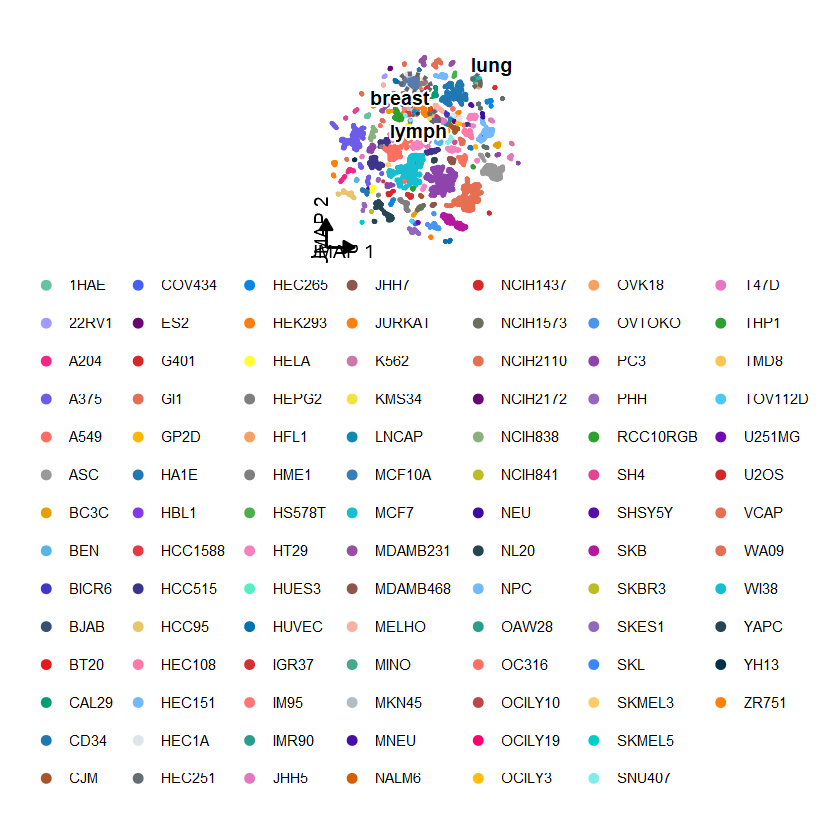

In [ ]:
library(ggplot2)
library(dplyr)
library(svglite)
library(ggrepel)

setwd("/umap")
data2 <- read.csv("umap.csv")

cell_centroids <- data2 %>%
  group_by(cell, tissue) %>%
  summarise(mean_x = median(umap_1, na.rm = TRUE), 
            mean_y = median(umap_2, na.rm = TRUE), 
            .groups = "drop")

dist_threshold <- (max(data2$umap_1, na.rm = TRUE) - min(data2$umap_1, na.rm = TRUE)) * 0.1

cluster_list <- list()
cluster_id <- 1

for (t in unique(cell_centroids$tissue)) {
  t_data <- cell_centroids %>% filter(tissue == t)
  
  if (nrow(t_data) > 1) {
    d <- dist(t_data[, c("mean_x", "mean_y")])
    hc <- hclust(d, method = "single")
    groups <- cutree(hc, h = dist_threshold)
    t_data$group <- groups
    
    for (g in unique(groups)) {
      cells_in_group <- t_data$cell[t_data$group == g]
      if (length(cells_in_group) >= 2) { 
        cluster_data <- data.frame(
          cell = cells_in_group, 
          ellipse_group = paste0("Tissue_", t, "_Group_", cluster_id), 
          ellipse_tissue = t
        )
        cluster_list[[cluster_id]] <- cluster_data
        cluster_id <- cluster_id + 1
      }
    }
  }
}

ellipse_mapping <- do.call(rbind, cluster_list)

if (!is.null(ellipse_mapping)) {
  ellipse_mapping_filtered <- ellipse_mapping %>%
    filter(!cell %in% exclude_cells) %>%
    filter(!ellipse_tissue %in% exclude_tissues)
  
  data2 <- data2 %>% left_join(ellipse_mapping_filtered, by = "cell")
} else {
  data2$ellipse_group <- NA
}

if ("ellipse_group" %in% colnames(data2) && any(!is.na(data2$ellipse_group))) {
  label_coords <- data2 %>%
    filter(!is.na(ellipse_group)) %>%
    group_by(ellipse_group, ellipse_tissue) %>%
    summarise(
      label_x = median(umap_1, na.rm = TRUE),
      label_y = median(umap_2, na.rm = TRUE),
      .groups = "drop"
    )
} else {
  label_coords <- data.frame(label_x = numeric(0), label_y = numeric(0), ellipse_tissue = character(0))
}

min_x <- min(data2$umap_1, na.rm = TRUE)
max_x <- max(data2$umap_1, na.rm = TRUE)
min_y <- min(data2$umap_2, na.rm = TRUE)
max_y <- max(data2$umap_2, na.rm = TRUE)

offset_x <- (max_x - min_x) * 0.03
offset_y <- (max_y - min_y) * 0.03
anchor_x <- min_x - offset_x
anchor_y <- min_y - offset_y
len_x <- (max_x - min_x) * 0.15
len_y <- (max_y - min_y) * 0.15

p <- ggplot(data2, aes(x = umap_1, y = umap_2)) +
  
  geom_point(aes(color = cell), size = 0.1, alpha = 1) + 
  
  stat_ellipse(
    data = data2 %>% filter(!is.na(ellipse_group)),
    aes(group = ellipse_group, fill = ellipse_tissue), 
    geom = "polygon",
    linetype = 2,           
    linewidth = 1,          
    alpha = 1/6,            
    color = "grey40",       
    show.legend = FALSE     
  ) +
  
  geom_text_repel(
    data = label_coords, 
    aes(x = label_x, y = label_y, label = ellipse_tissue),
    inherit.aes = FALSE,
    size = 4, 
    fontface = "bold", 
    color = "black",
    bg.color = "white",
    bg.r = 0.15 
  ) +
  
  theme_void() + 
  theme(
    legend.title = element_blank(),
    legend.position = "bottom", 
    plot.margin = margin(1, 1, 1, 1, "cm"), 
    plot.background = element_rect(fill = "white", color = NA), 
    panel.background = element_rect(fill = "white", color = NA) 
  ) +
  guides(
    color = guide_legend(
      title = "Cell",
      title.position = "top",
      nrow = 14, 
      override.aes = list(size = 2, alpha = 1)
    )
  ) +
  coord_fixed(ratio = 1) +
  scale_color_manual(values = setNames(data2$color, data2$cell)) +
  
  annotate("segment", x = anchor_x, y = anchor_y, xend = anchor_x, yend = anchor_y + len_y,
           arrow = arrow(length = unit(0.25, "cm"), ends = "last", type = "closed"), linewidth = 0.6) +
  annotate("segment", x = anchor_x, y = anchor_y, xend = anchor_x + len_x, yend = anchor_y,
           arrow = arrow(length = unit(0.25, "cm"), ends = "last", type = "closed"), linewidth = 0.6) +
  annotate("text", x = anchor_x - offset_x * 0.8, y = anchor_y + len_y/2, label = "UMAP 2", angle = 90, vjust = 0.5, size = 4) +
  annotate("text", x = anchor_x + len_x/2, y = anchor_y - offset_y * 0.8, label = "UMAP 1", hjust = 0.5, size = 4)

p

ggsave("UMAP_cell_plot_AI_ready_clustered_labeled.svg", 
       plot = p,
       device = svglite, 
       width = 10, 
       height = 11, 
       units = "in"
)